# Random-Forest Baseline v2

Dieses Notebook zeigt die optimierte zweite Version der Random-Forest-Baseline inklusive Search-Ergebnissen, Modellmetriken und grafischer Confusion Matrix.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src" / "random_forest_baseline_v2").exists():
            return candidate
    raise FileNotFoundError("Repo root mit src/random_forest_baseline_v2 wurde nicht gefunden.")

repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.random_forest_baseline.config import BaselineConfig
from src.random_forest_baseline.data import prepare_dataset
from src.random_forest_baseline.modeling import evaluate_grouped_dataset, save_confusion_matrix_plot

config = BaselineConfig.from_json(repo_root / "baseline_models/random_forest_v2/config.json")
config

BaselineConfig(data_dir='Daten/Daten_Labeled', output_dir='baseline_models/random_forest_v2/output', model_output_path='baseline_models/random_forest_v2/output/random_forest_model.pkl', window_before_s=0.5, window_after_s=0.5, min_window_rows=25, labels=['Vorhand', 'Rueckhand', 'Schlaeger drehen', 'Aufschlag von unten', 'Kein Schlag / Other'], excluded_labels=['Unsicher'], min_samples_per_label=10, min_sessions_per_label=2, random_state=42, n_estimators=600, max_depth=12, min_samples_split=6, min_samples_leaf=2, max_features=0.5, criterion='entropy', class_weight='balanced')

In [2]:
search_results_path = repo_root / "baseline_models/random_forest_v2/output/search_results.csv"
search_summary_path = repo_root / "baseline_models/random_forest_v2/output/search_summary.json"
if search_results_path.exists():
    display(pd.read_csv(search_results_path).head(10))
if search_summary_path.exists():
    display(pd.DataFrame([json.loads(search_summary_path.read_text())]))

,search_rank,candidate_rank_seed_order,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,criterion,class_weight,event_count,feature_count,session_count,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,1,14,600,6,2,0.5,12.0,entropy,balanced,377.0,164.0,3.0,0.891247,0.763091,0.745626,0.763091,0.752064,0.889265
1,2,9,600,10,3,log2,12.0,entropy,balanced_subsample,377.0,164.0,3.0,0.899204,0.757166,0.740410,0.757166,0.746488,0.895040
2,3,1,200,6,4,0.5,12.0,gini,NaN,377.0,164.0,3.0,0.891247,0.751763,0.745619,0.751763,0.744177,0.879097
3,4,3,200,6,2,0.75,8.0,entropy,balanced_subsample,377.0,164.0,3.0,0.891247,0.752708,0.732850,0.752708,0.741680,0.885983
4,5,7,300,4,4,log2,8.0,gini,balanced,377.0,164.0,3.0,0.893899,0.751287,0.734302,0.751287,0.740732,0.890862
5,6,16,300,6,1,0.75,NaN,entropy,balanced_subsample,377.0,164.0,3.0,0.888594,0.751531,0.731482,0.751531,0.740179,0.884879
6,7,4,300,6,4,sqrt,8.0,entropy,balanced_subsample,377.0,164.0,3.0,0.885942,0.747579,0.734108,0.747579,0.739597,0.887701
7,8,11,200,4,1,log2,NaN,entropy,balanced,377.0,164.0,3.0,0.899204,0.747503,0.737851,0.747503,0.739476,0.890971
8,9,12,800,4,3,log2,12.0,gini,balanced,377.0,164.0,3.0,0.891247,0.749003,0.731718,0.749003,0.738866,0.889350
9,10,6,200,4,2,0.5,24.0,entropy,balanced_subsample,377.0,164.0,3.0,0.891247,0.757723,0.722245,0.757723,0.738132,0.886429


,best_params,best_metrics,search_space,n_iter
0,"{'n_estimators': 600, 'max_depth': 12, 'min_sa...","{'accuracy': 0.8912466843501327, 'balanced_acc...","{'n_estimators': [200, 300, 400, 600, 800], 'm...",16


In [3]:
dataset = prepare_dataset(config)
display(dataset.label_summary)
display(dataset.metadata.head())
print(f"Events: {len(dataset.labels)} | Sessions: {dataset.groups.nunique()} | Features: {dataset.features.shape[1]}")

,label_name,total_events,session_count
0,Vorhand,170,3
1,Rueckhand,95,3
2,Schlaeger drehen,53,2
3,Aufschlag von unten,38,2
4,Kein Schlag / Other,21,3


,session_name,event_index,event_time_s,window_start_s,window_end_s,window_rows,label_name
0,fritz_1_Labeled.csv,11534,116.219257,115.719257,116.719257,99,Rueckhand
1,fritz_1_Labeled.csv,11832,119.222006,118.722006,119.722006,99,Rueckhand
2,fritz_1_Labeled.csv,12133,122.254987,121.754987,122.754987,99,Vorhand
3,fritz_1_Labeled.csv,12499,125.942926,125.442926,126.442926,99,Vorhand
4,fritz_1_Labeled.csv,12805,129.026281,128.526281,129.526281,99,Vorhand


Events: 377 | Sessions: 3 | Features: 164


In [4]:
result = evaluate_grouped_dataset(dataset, config)
display(pd.DataFrame([result.overall_metrics]))
display(result.classification_report)
display(result.fold_metrics)

,event_count,feature_count,session_count,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,377.0,164.0,3.0,0.891247,0.763091,0.745626,0.763091,0.752064,0.889265


,label,precision,recall,f1-score,support
0,Vorhand,0.981818,0.952941,0.967164,170.000000
1,Rueckhand,0.945055,0.905263,0.924731,95.000000
2,Schlaeger drehen,0.772727,0.962264,0.857143,53.000000
3,Aufschlag von unten,0.972973,0.947368,0.960000,38.000000
4,Kein Schlag / Other,0.055556,0.047619,0.051282,21.000000
5,accuracy,0.891247,0.891247,0.891247,0.891247
6,macro avg,0.745626,0.763091,0.752064,377.000000
7,weighted avg,0.890672,0.891247,0.889265,377.000000


,fold,test_session,train_events,test_events,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,1,fritz_1_Labeled.csv,230,147,0.870748,0.720898,0.780193,0.720898,0.747499,0.920280
1,2,fritz_2_Labeled.csv,292,85,0.929412,0.666667,0.495763,0.500000,0.497863,0.923580
2,3,fritz_3_Labeled.csv,232,145,0.889655,0.791534,0.914109,0.791534,0.767347,0.856185


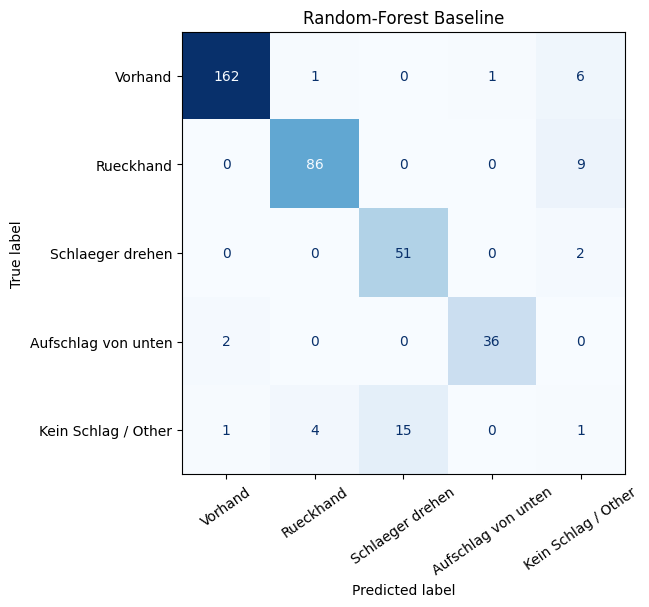

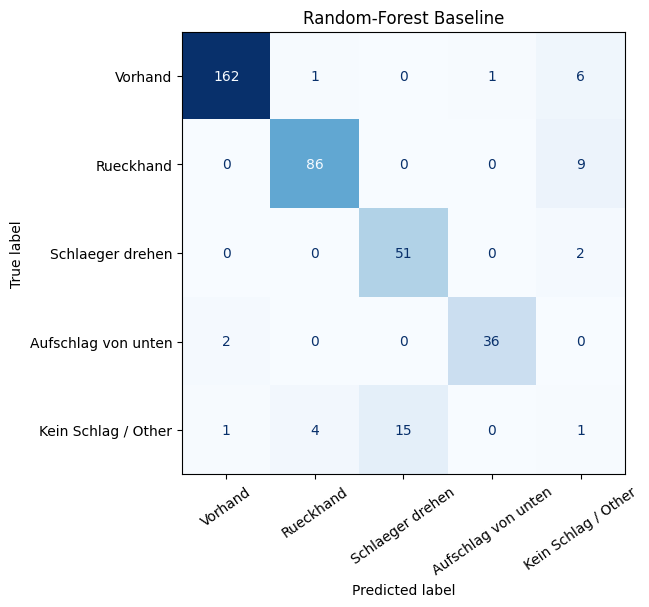

In [5]:
figure = save_confusion_matrix_plot(result.confusion_matrix)
figure